In [185]:
import os
import json
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
DATA_PATH = "data/transit_ridership.csv"
OUTPUT_DIR = "output"

In [186]:
def load_data(filepath):
    """Load transit ridership data with basic validation."""
    # try:
    #     df = pd.read_csv(filepath)
    # except FileNotFoundError:
    #     raise FileNotFoundError(f"File not found: {filepath}")

    # print(f"Loaded {len(df)} records from {filepath}")

    required_columns = [
        "date",
        "route_id",
        "direction",
        "boarding_count",
        "alighting_count",
        "vehicle_type",
        "trip_duration_min",
        "weather",
        "temperature_c",
        "is_holiday",
    ]

    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    return df

In [187]:
df = pd.read_csv('data/transit_ridership.csv')

In [188]:
load_data(df)

,date,route_id,direction,boarding_count,alighting_count,vehicle_type,trip_duration_min,weather,temperature_c,is_holiday
0,2024-10-21,R205,Inbound,388.0,57.0,Minibus,77.9,Clear,-14.3,false
1,2024-08-29,R105,Outbound,457.0,169.0,Articulated Bus,76.6,Snow,-1.1,false
2,2024-08-31,R207,Inbound,NaN,518.0,Articulated Bus,58.5,Overcast,22.8,False
3,2024-12-24,R208,Outbound,354.0,302.0,Articulated Bus,47.4,Snow,29.6,0
4,2024-03-05,R207,Inbound,423.0,643.0,Minibus,17.4,Overcast,-11.7,No
...,...,...,...,...,...,...,...,...,...,...
1988,2024-07-07,R104,Inbound,216.0,599.0,Articulated Bus,82.2,Snow,29.7,0
1989,2024-06-11,R104,Outbound,41.0,464.0,Minibus,76.9,Snow,21.0,0
1990,2024-09-29,R205,Outbound,103.0,413.0,Minibus,55.8,Rain,-3.3,False
1991,2024-10-21,R206,Inbound,139.0,623.0,Articulated Bus,21.7,Overcast,36.9,false


In [189]:
def clean_data(df):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df.dropna(subset=["date"])

    df["weather"] = df["weather"].str.lower().str.strip()
    df["direction"] = df["direction"].str.lower().str.strip()
    df["vehicle_type"] = df["vehicle_type"].str.lower().str.strip()

    df["boarding_count"] = df["boarding_count"].fillna(0)
    df["alighting_count"] = df["alighting_count"].fillna(0)
    df["temperature_c"] = df["temperature_c"].fillna(df["temperature_c"].median())
    df["trip_duration_min"] = df["trip_duration_min"].fillna(df["trip_duration_min"].median())

    df = df[df["boarding_count"] >= 0]
    df = df[df["alighting_count"] >= 0]
    df = df[df["trip_duration_min"] > 0]

    df = df.drop_duplicates()

    print(f"Cleaned data: {len(df)} records")
    return df

In [190]:

clean_data(df)

Cleaned data: 1743 records


,date,route_id,direction,boarding_count,alighting_count,vehicle_type,trip_duration_min,weather,temperature_c,is_holiday
0,2024-10-21,R205,inbound,388.0,57.0,minibus,77.9,clear,-14.3,false
1,2024-08-29,R105,outbound,457.0,169.0,articulated bus,76.6,snow,-1.1,false
2,2024-08-31,R207,inbound,0.0,518.0,articulated bus,58.5,overcast,22.8,False
3,2024-12-24,R208,outbound,354.0,302.0,articulated bus,47.4,snow,29.6,0
4,2024-03-05,R207,inbound,423.0,643.0,minibus,17.4,overcast,-11.7,No
...,...,...,...,...,...,...,...,...,...,...
1988,2024-07-07,R104,inbound,216.0,599.0,articulated bus,82.2,snow,29.7,0
1989,2024-06-11,R104,outbound,41.0,464.0,minibus,76.9,snow,21.0,0
1990,2024-09-29,R205,outbound,103.0,413.0,minibus,55.8,rain,-3.3,False
1991,2024-10-21,R206,inbound,139.0,623.0,articulated bus,21.7,overcast,36.9,false


In [191]:
def add_features(df):
    df = df.copy()

    df["total_passengers"] = df["boarding_count"] + df["alighting_count"]
    df["day_of_week"] = df["date"].dt.day_name()
    df["month"] = df["date"].dt.month

    return df

In [ ]:
def create_visualizations(df):
    df = df.copy()

    df["total_passengers"] = df["boarding_count"] + df["alighting_count"]
   
    
    monthly = df.groupby(df["date"].dt.month)["boarding_count"].sum()
    fig, ( (ax0,ax1) , (ax2,ax3) )=  plt.subplots(2,2,figsize=(20,20))

    ax0.plot(monthly.index, monthly.values, marker='o')    
    ax0.set(title="Total Boarding by Month", xlabel="Month" , ylabel="Total Boarding")
    ax0.tick_params(axis= "x", rotation=45)

    route_boarding = df.groupby("route_id")["boarding_count"].sum()
    ax1.barh(route_boarding.index, route_boarding.values)
    ax0.set(title="Total Boarding by Route", xlabel="Total Boarding" , ylabel="Route")

    vehicle_avg = df.groupby("vehicle_type")["trip_duration_min"].mean().sort_values(ascending=False)
    ax2.bar(vehicle_avg.index, vehicle_avg.values)
    ax2.set(title="Average Trip Duration by Vehicle Type", xlabel="Vehicle Type", ylabel="Average Trip Duration (min)")

    df["weather"] = df["weather"].str.strip().str.title()
    weather_avg = df.groupby("weather")["boarding_count"].mean()
    colors = ["orange", "blue", "red", "purple"]
    weather_avg = weather_avg.reindex(["Snow", "Clear", "Rain", "Overcast"])


    ax3.bar(weather_avg.index, weather_avg.values, color=colors)
    ax3.set_title("Average Boardings by Weather Condition")
    ax3.set_xlabel("Weather Condition")
    ax3.set_ylabel("Average Boardings per Trip")
    fig.savefig("output/Stretch_assigment")



In [193]:
def generate_summary(df):

    if df.empty:
        return {
            "total_trips": 0,
            "date_range": None,
            "busiest_route": None,
            "avg_daily_ridership": 0,
            "ridership_by_vehicle_type": {},
            "ridership_by_weather": {},
            "top_5_routes_by_boarding": []
        }

    total_trips = len(df)

    start = df["date"].min().date()
    end = df["date"].max().date()
    date_range = f"{start.isoformat()} to {end.isoformat()}"

    
    route_totals = df.groupby("route_id")["boarding_count"].sum()
    busiest_route = route_totals.idxmax()

    daily = df.groupby("date")["boarding_count"].sum()
    avg_daily_ridership = float(round(daily.mean(), 1))

    vehicle = df.groupby("vehicle_type")["boarding_count"].sum()
    ridership_by_vehicle_type = dict(sorted(
        ((k, int(v)) for k, v in vehicle.items())
    ))

    weather = df.groupby("weather")["boarding_count"].sum()
    ridership_by_weather = dict(sorted(
        ((k, int(v)) for k, v in weather.items())
    ))

    top_routes = route_totals.sort_values(ascending=False).head(5)
    top_5_routes = [
        {"route": r, "total_boardings": int(v)}
        for r, v in top_routes.items()
    ]

    return {
        "total_trips": int(total_trips),
        "date_range": date_range,
        "busiest_route": busiest_route,
        "avg_daily_ridership": avg_daily_ridership,
        "ridership_by_vehicle_type": ridership_by_vehicle_type,
        "ridership_by_weather": ridership_by_weather,
        "top_5_routes_by_boarding": top_5_routes
    }

In [194]:
def save_summary(summary, output_dir=OUTPUT_DIR):
    os.makedirs(output_dir, exist_ok=True)
    with open(f"{output_dir}/summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    print("Summary saved.")

Cleaned data: 1743 records
{'total_trips': 1743, 'date_range': '2024-01-01 to 2024-12-31', 'busiest_route': 'R208', 'avg_daily_ridership': 1834.0, 'ridership_by_vehicle_type': {'articulated': 2404, 'articulated bus': 209454, 'mini bus': 3365, 'minibus': 230942, 'standard bus': 215546, 'std bus': 4045}, 'ridership_by_weather': {'clear': 156285, 'overcast': 177364, 'rain': 174014, 'snow': 158093}, 'top_5_routes_by_boarding': [{'route': 'R208', 'total_boardings': 65815}, {'route': 'R105', 'total_boardings': 65506}, {'route': 'R206', 'total_boardings': 64158}, {'route': 'R205', 'total_boardings': 60840}, {'route': 'R104', 'total_boardings': 60533}]}
Summary saved.
Pipeline complete!


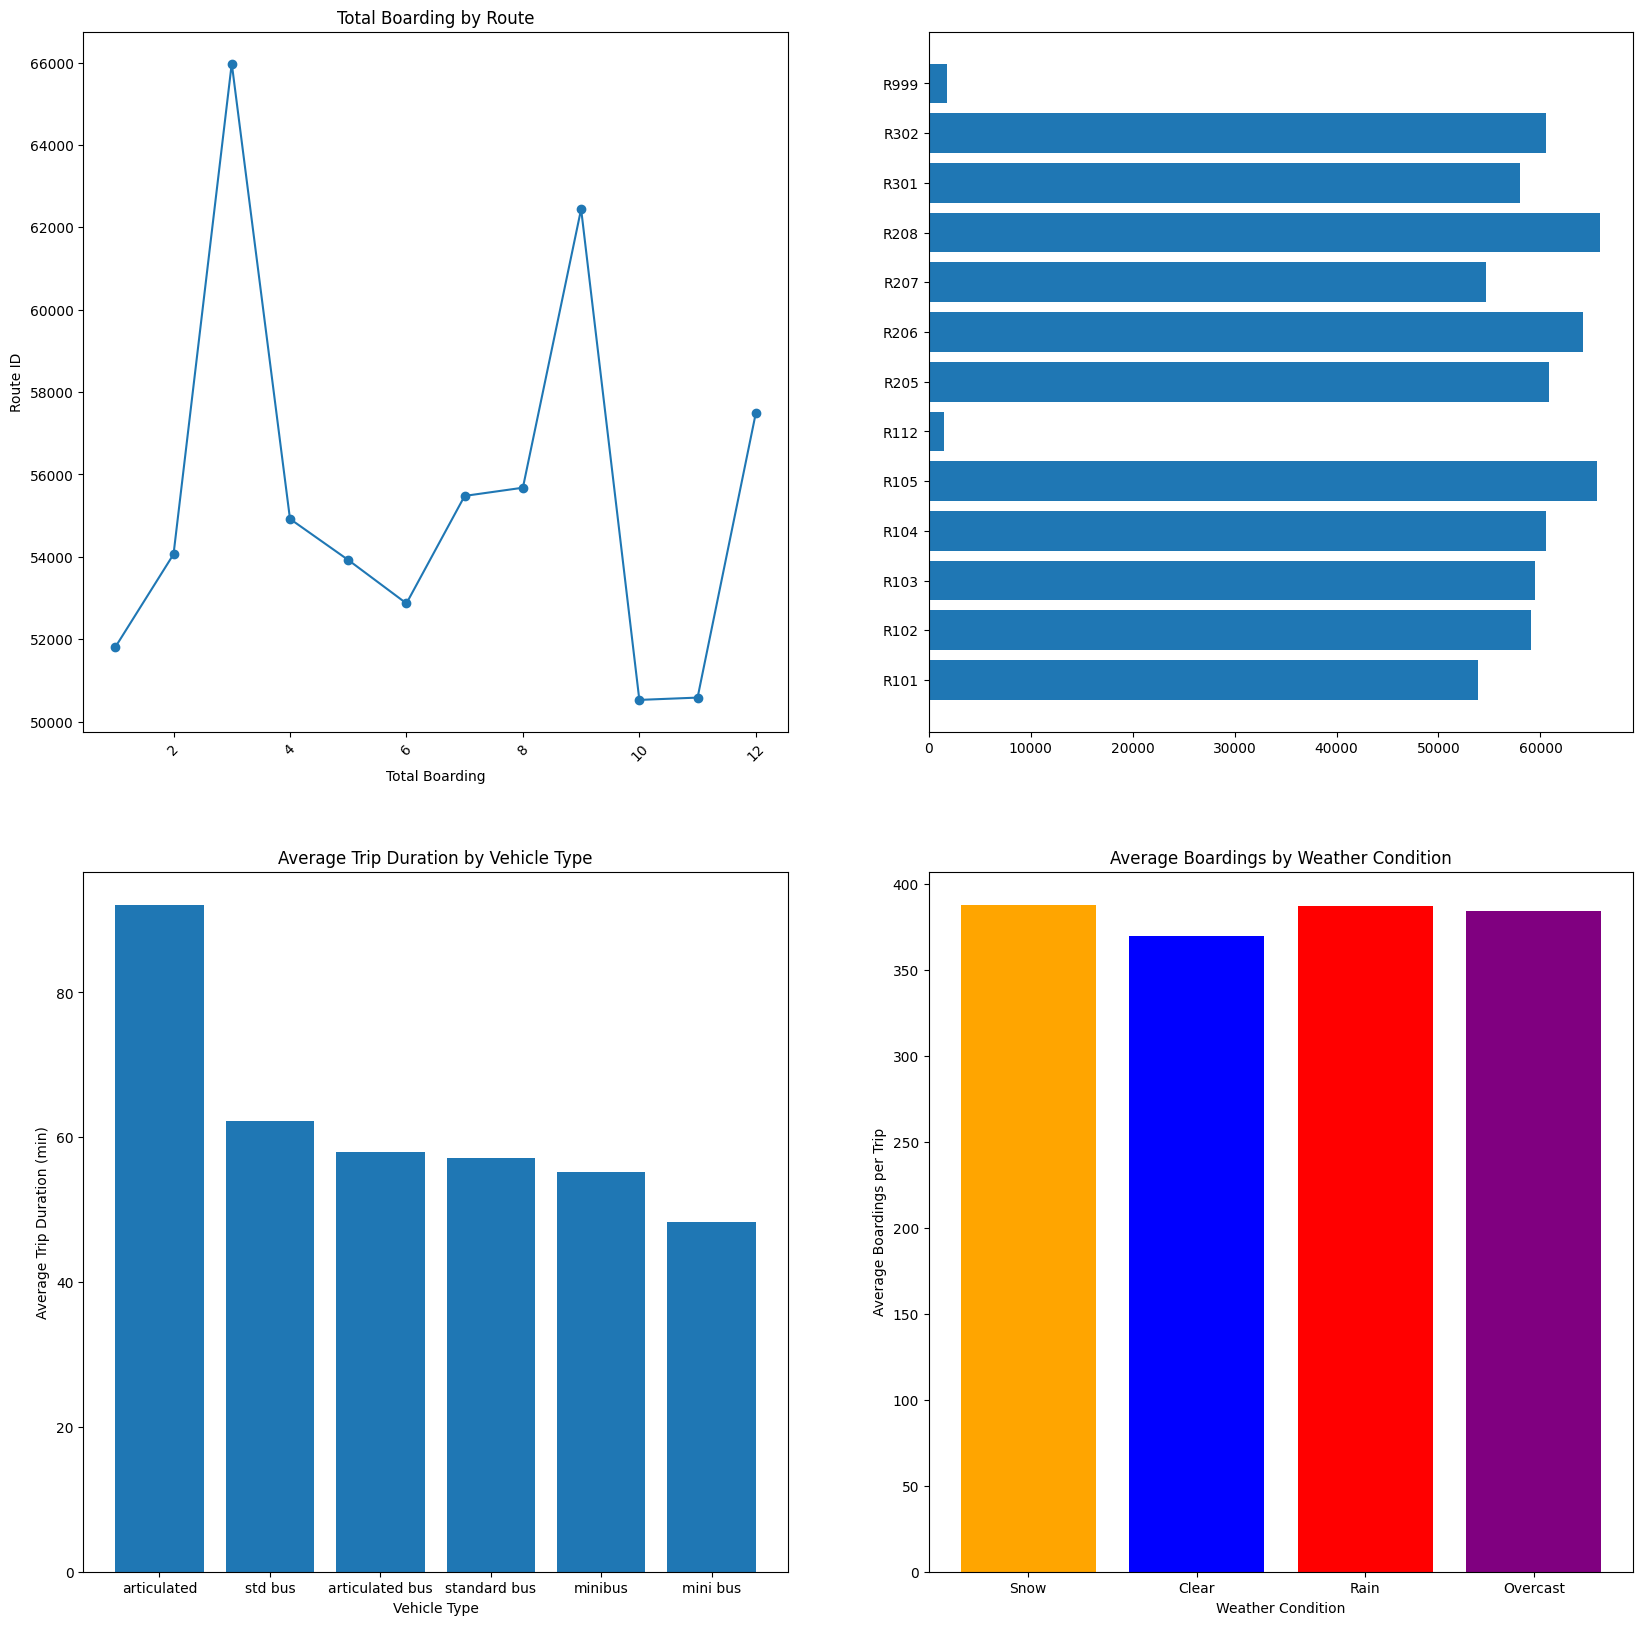

In [195]:
def main():
    df = load_data(DATA_PATH)
    df = clean_data(df)
    df = add_features(df)

    summary = generate_summary(df)
    print(summary)

    save_summary(summary)
    create_visualizations(df)

    print("Pipeline complete!")

    
if __name__ == "__main__":
    main()